In [4]:
#{pruning%: {cluster: {neuron 1: [concepts], neuron2: [concdpets]}, cluster2: {neuonrs: concept}} pruning %: ...}
import torch
import pandas as pd
import os, collections
import re
def get_grouped_concepts(formula) -> list:
    stack = []
    results = []
    for i, char in enumerate(formula):
        if char == '(':
            stack.append(i)
        elif char == ')' and stack:
            start = stack.pop()
            results.append(formula[start:i+1])
    return results

def get_indiv_concepts(formula) -> list:
    concepts=[]
    concps = re.findall(r'\b(?:NOT )?(?:pre:tok:|pre:tag:|hyp:tag:|hyp:tok:|oth:)\S*', formula)
    for c in concps:
        try:
            end_idx =c.index(')')
        except:
            end_idx = len(c)
        concepts.append(c[:end_idx])
    return concepts
                
def get_collected_concepts(root):
    concepts_per_neuron_per_cluster_per_pruningIteration = collections.defaultdict(lambda : collections.defaultdict(lambda : collections.defaultdict(list)))
    #for each pruning iter
    for pruning_iter in os.listdir(root):
        if '.ipynb' in pruning_iter: continue
        pruned_percent = pruning_iter[:pruning_iter.index("_")]
        #for each cluster
        for cluster in os.listdir(os.path.join(root, pruning_iter)):
            if cluster == 'result.csv' or '.ipy' in cluster: continue
  
            cluster_num = cluster[7]
            for row in pd.read_csv(os.path.join(root, pruning_iter, cluster)).iterrows(): #fix this
                row = row[1]
                neuron, formula, iou = row.unit, row.best_name,float("{:.3f}".format(row.best_iou))
                formula = get_indiv_concepts(formula)
                #print(formula)
                for concept in formula:
                    # If concept doesn't exist, initialize all nested levels
                    if concept not in concepts_per_neuron_per_cluster_per_pruningIteration:
                        concepts_per_neuron_per_cluster_per_pruningIteration[concept] = {}

                    prune_key = f"{pruned_percent}% Prune"
                    if prune_key not in concepts_per_neuron_per_cluster_per_pruningIteration[concept]:
                        concepts_per_neuron_per_cluster_per_pruningIteration[concept][prune_key] = {
                            f"Cluster{i}": [] for i in range(1,4)
                        }

                    cluster_key = f"Cluster{cluster_num}"
                    if cluster_key not in concepts_per_neuron_per_cluster_per_pruningIteration[concept][prune_key]:
                        concepts_per_neuron_per_cluster_per_pruningIteration[concept][prune_key][cluster_key] = []

                    # Now append the neuron info
                    concepts_per_neuron_per_cluster_per_pruningIteration[concept][prune_key][cluster_key].append(f"Neuron {neuron}: IOU:{iou}")
    return concepts_per_neuron_per_cluster_per_pruningIteration
root="bert/wanda/RunBERTToVerifyFormulaMaskOveralpComp/Expls" # "bowman/wanda/RunBowmanWandaReformatted/Expls" #"bowman/lottery_ticket/RunFIXEDLTH/Expls" #"bert/lottery_ticket/RunBERT_LTHFIXED/Expls/" #"bert/wanda/RunBERT/Expls/"  #bowman/lottery_ticket/RunFIXEDLTH/Expls
    
concepts=get_collected_concepts(root)

def find_concept_details(concept):
    concept_dict= concepts[concept]
    try:
        original_scrapes = concept_dict["0.0% Prune"]
        print(f"In original at \n\tCluster 1: {original_scrapes['Cluster1']}\n\tCluster 2: {original_scrapes['Cluster2']}\n\tCluster 3: {original_scrapes['Cluster3']}")
    except:
        print(f"{concept} not in orig")
    for percent in sorted(concept_dict.keys()):
        if "0.0%" in percent and "20.0" not in percent: continue
        pruned_scrapes = concept_dict[percent]
        print(f"At {percent}% at \n\tCluster 1: {pruned_scrapes['Cluster1']}\n\tCluster 2: {pruned_scrapes['Cluster2']}\n\tCluster 3: {pruned_scrapes['Cluster3']}")


In [5]:
title = 'bert/wanda'
root="bert/wanda/RunBERTToVerifyFormulaMaskOveralpComp/Expls"
concepts=get_collected_concepts(root)
def shift(concepts):  
    prune_percents = get_all_pruned_iters(concepts)
    '''
        Takes the concetp dict and returns the ratio between functional and token concepts
        in the context of neurons shifting across clusters between iterations 
        note: this means that if a concept is explain by neuron 5 in cluster 1, then after pruning, neuron 5 is explaining
        the concept, but in cluster 3, then neuron 5 is "shifted"
    '''
    shifts = collections.defaultdict(dict)
    for concept in concepts.keys():

        originally_active_neurons = getActiveNeurons(concepts[concept], '0.0% Prune')
        
        if not originally_active_neurons: continue

        for pi in prune_percents:
            if pi == '0.0% Prune': continue
            neurons_active_at_pi = getActiveNeurons(concepts[concept], pi)
            if not neurons_active_at_pi: continue 
            
            shifts[concept][pi] = count_shifts(originally_active_neurons, neurons_active_at_pi)
            if  shifts[concept][pi]  == 0:
                print(f"There were no shifting neurons with concept {concept} and pruning iteration {pi}")
                print(f"Originally {originally_active_neurons} were active, now {neurons_active_at_pi} are")
    counts = count_func_tok(shifts)
    
    for p in counts:
        for neur in counts[p]:
            funcc = counts[p][neur]['functional'] 
            tokk = counts[p][neur]['token'] 
            counts[p][neur]['functional']  /= (funcc+tokk)
            counts[p][neur]['token']  /= (funcc+tokk)
    return counts
shift(concepts)

NameError: name 'get_all_pruned_iters' is not defined

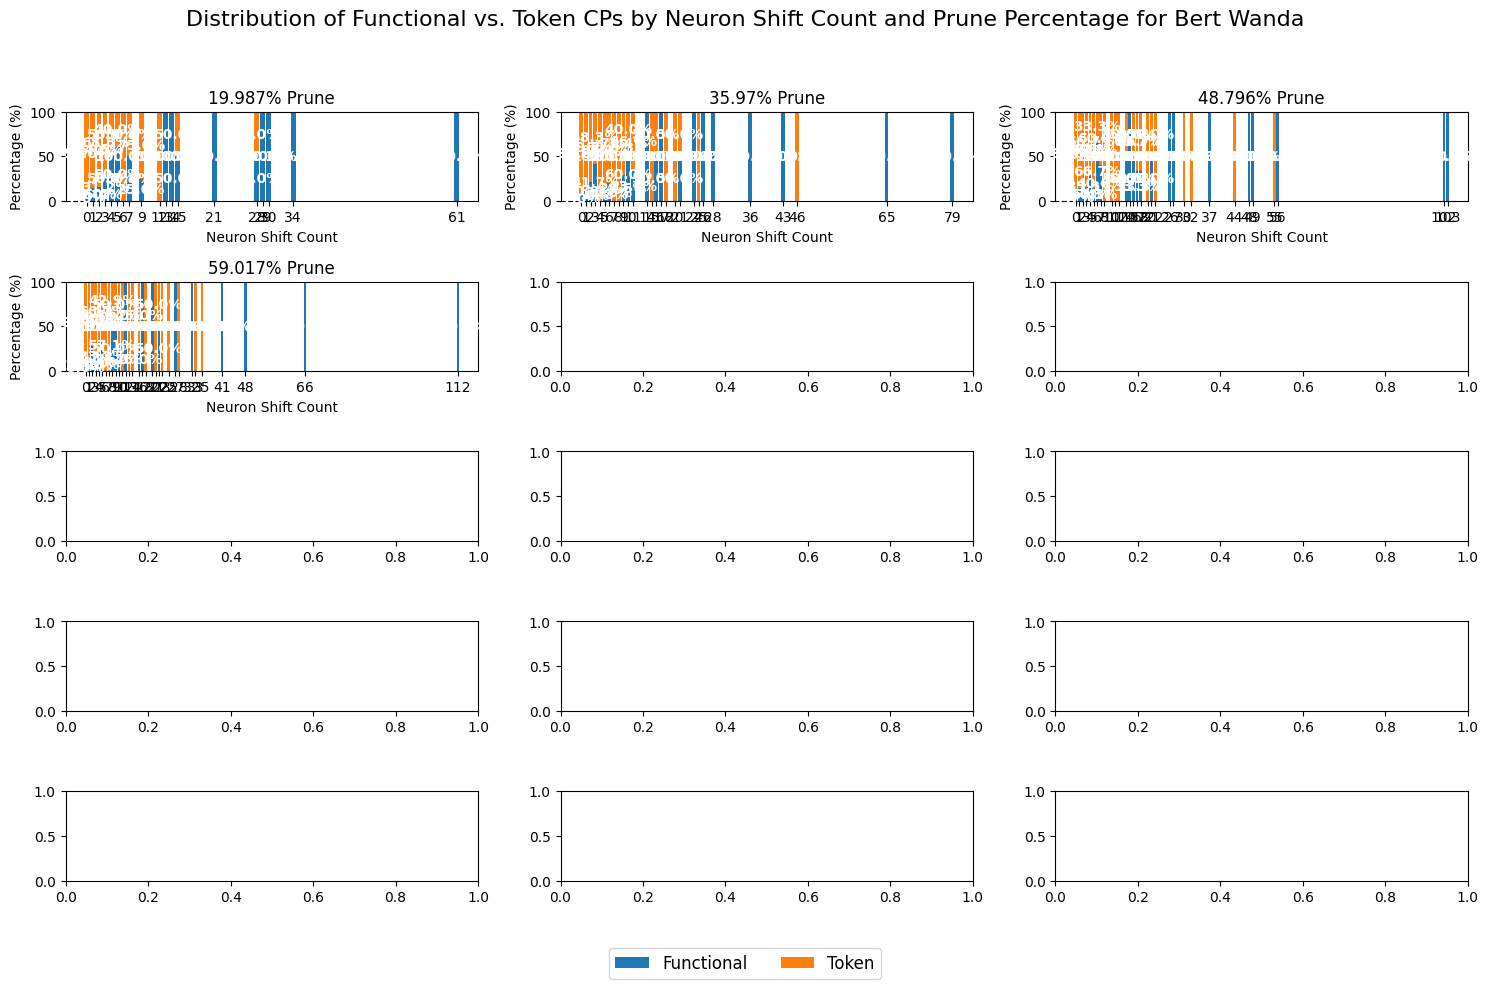

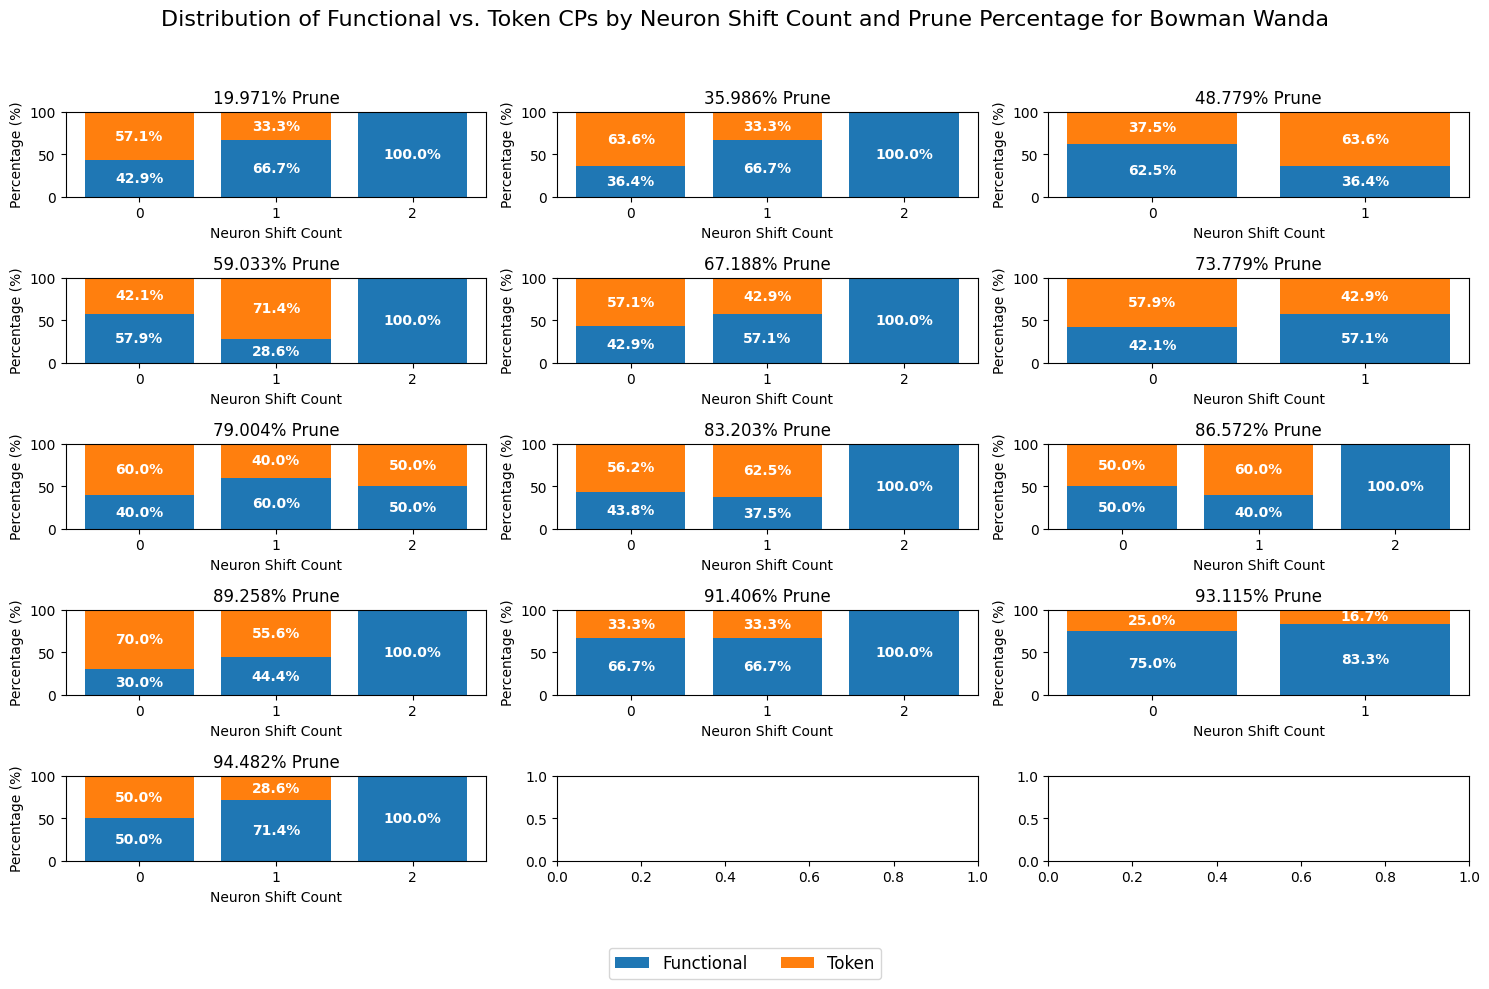

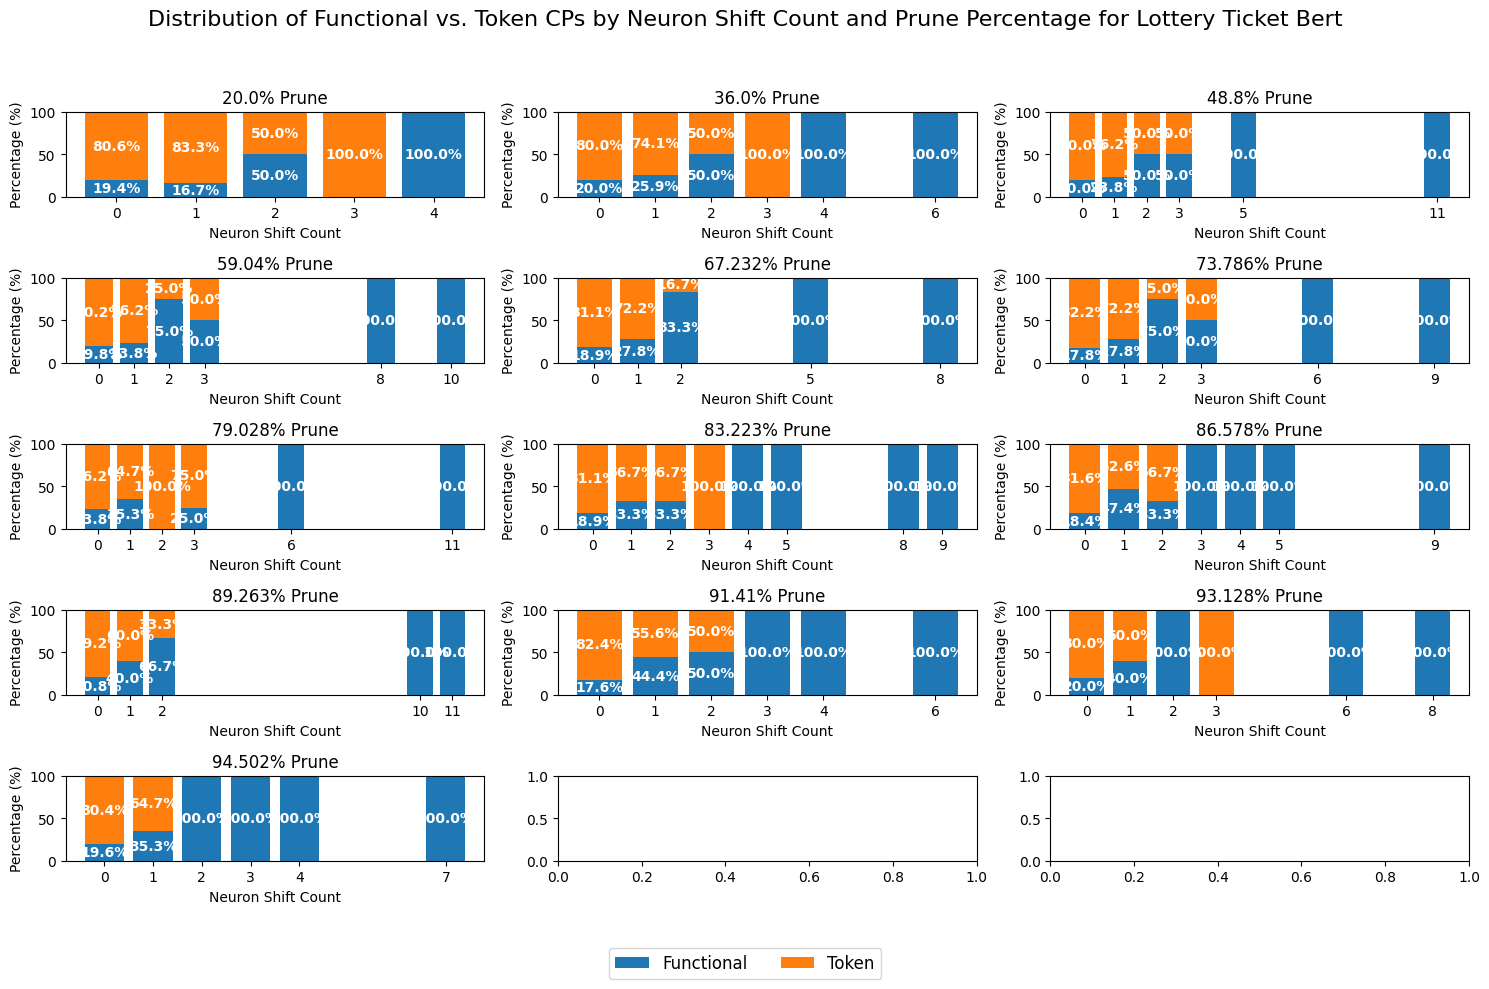

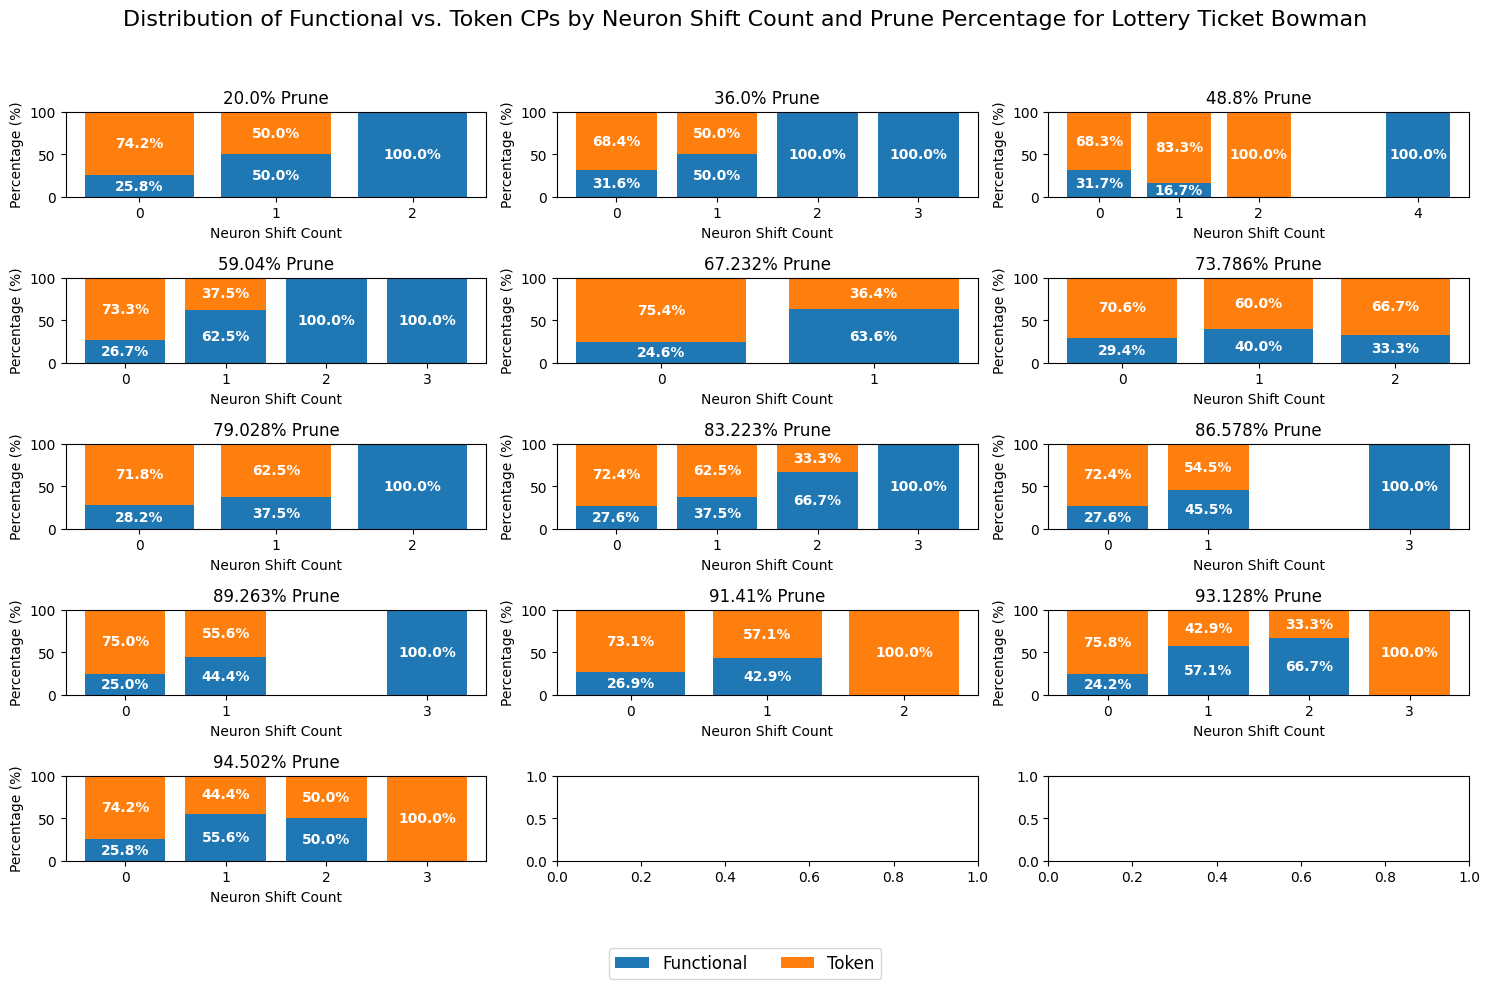

In [13]:

def count_shifts(og, pruned):
    """
        counts the number of neurons that shift for a given concept and pruning iteration
    """
    moved = 0
    clusters_to_check = [(2,3), (1,3), (1,2)]
    for cluster in og.keys():
        counted=[]
        cluster_num = int(cluster[-1:])
        neurons_to_exclude = set(og[f"Cluster{cluster_num}"]) & set(pruned[f"Cluster{cluster_num}"])
        for og_clus in clusters_to_check[cluster_num-1]:
            for neur in og[f"Cluster{og_clus}"]:
                # if the neuron in the other clusters in og is in this pruning cluster (taking into account that the neur may be explained at other clusters in the og)
                # that means those neurons moved
                if neur in pruned[cluster] and neur not in neurons_to_exclude:
                    if neur in counted: continue
                    counted.append(neur)
                    moved += 1
    return moved
        
    
def shift(concepts):  
    prune_percents = get_all_pruned_iters(concepts)
    '''
        Takes the concetp dict and returns the ratio between functional and token concepts
        in the context of neurons shifting across clusters between iterations 
        note: this means that if a concept is explain by neuron 5 in cluster 1, then after pruning, neuron 5 is explaining
        the concept, but in cluster 3, then neuron 5 is "shifted"
    '''
    shifts = collections.defaultdict(dict)
    for concept in concepts.keys():

        originally_active_neurons = getActiveNeurons(concepts[concept], '0.0% Prune')
        
        if not originally_active_neurons: continue

        for pi in prune_percents:
            if pi == '0.0% Prune': continue
            neurons_active_at_pi = getActiveNeurons(concepts[concept], pi)
            if not neurons_active_at_pi: continue 
            shifts[concept][pi] = count_shifts(originally_active_neurons, neurons_active_at_pi)
           
    counts = count_func_tok(shifts)
    
    for p in counts:
        for neur in counts[p]:
            funcc = counts[p][neur]['functional'] 
            tokk = counts[p][neur]['token'] 
            counts[p][neur]['functional']  /= (funcc+tokk)
            counts[p][neur]['token']  /= (funcc+tokk)
    return counts

def count_func_tok(shifts):
    '''
        Counts number of functional and token conceots at each pruning iter and number of neurons that shift
        ex: if 0 neurons shift at 20% pruning for 5 concepts of which 2 are functional and 3 are tokens, 
        for prune_iter 20%, # of shifting neurons 0, it will return 2 functional, 3 tokens
    '''
    news=collections.defaultdict(lambda: collections.defaultdict(lambda: {'functional': 0, 'token': 0}))
    for c in shifts:
        for p, v in shifts[c].items():
            if v not in news[p]:
                if ':tag:' in c or ':overlap:' in c or c in f_c:
                    news[p][v]['functional'] =  1
                else:
                    news[p][v]['token'] = 1
            else:
                if ':tag:' in c or ':overlap:' in c or c in f_c:
                    news[p][v]['functional'] += 1
                else:
                    news[p][v]['token'] += 1
    return news
# these tell you what percent of concepts where x neurons shift from orig are func or token
# shift doesnt mean lost, it just means moving clusters. so a iteration can have 0 shifted neurons but all neurons from orig are lost
title = 'bert/wanda'
root="bert/wanda/Run2FIXEDLTH/Expls"
concepts=get_collected_concepts(root)
shift_rates = shift(concepts)  #on avg 0.35 neurons shift at 73% pruning
graph_neuron_shift(shift_rates, "Bert Wanda") #neurons move for functional concepts not so much for token 
    #explaing: ex: 19%,  82.9% of the concepts where there is no neuron shifting are token
    #all concepts where 2 neurons shift in 19% are functinoal (overlpa, tags,in,and,etc)
    
title = 'bowman/wanda'
root="bowman/wanda/RunBowmanWandaReformatted/Expls"
concepts=get_collected_concepts(root)
shift_rates = shift(concepts)  #on avg 0.35 neurons shift at 73% pruning
graph_neuron_shift(shift_rates, "Bowman Wanda") #neurons move for functional concepts not so much for token 
    #explaing: ex: 19%,  82.9% of the concepts where there is no neuron shifting are token
    #all concepts where 2 neurons shift in 19% are functinoal (overlpa, tags,in,and,etc)
    
title = 'bert/lottery_ticket'
root="bert/lottery_ticket/RunBERT_LTHFIXED/Expls/"
concepts=get_collected_concepts(root)
shift_rates = shift(concepts)  #on avg 0.35 neurons shift at 73% pruning
graph_neuron_shift(shift_rates, "Lottery Ticket Bert") #neurons move for functional concepts not so much for token 
    #explaing: ex: 19%,  82.9% of the concepts where there is no neuron shifting are token
    #all concepts where 2 neurons shift in 19% are functinoal (overlpa, tags,in,and,etc)
    
title = 'bowman/lottery_ticket'
root="bowman/lottery_ticket/Run2FIXEDLTH/Expls"
concepts=get_collected_concepts(root)
shift_rates = shift(concepts)  #on avg 0.35 neurons shift at 73% pruning
graph_neuron_shift(shift_rates, "Lottery Ticket Bowman") #neurons move for functional concepts not so much for token 
    #explaing: ex: 19%,  82.9% of the concepts where there is no neuron shifting are token
    #all concepts where 2 neurons shift in 19% are functinoal (overlpa, tags,in,and,etc)
    
#finding: for bert the concepts that shift more neurons are functional, token shift fewer (but they still might be lost more)
#do this per concept as well (mean, kl div, median, other stats to show the shift)

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import re
from collections import defaultdict
def graph_neuron_shift(raw_data, title):
    prune_percentages = sorted(raw_data.keys(), 
                              key=lambda x: float(re.search(r'(\d+\.\d+)', x).group(1)))

    # Create a figure with subplots
    fig, axes = plt.subplots(5,3, figsize=(15, 10))
    axes = axes.flatten()

    colors = {'functional': '#1f77b4', 'token': '#ff7f0e'}

    # Plot each prune percentage as a separate subplot
    for i, prune_pct in enumerate(prune_percentages):
        shift_counts = sorted(raw_data[prune_pct].keys())
        functional_values = [raw_data[prune_pct][count]['functional'] * 100 for count in shift_counts]
        token_values = [raw_data[prune_pct][count]['token'] * 100 for count in shift_counts]

        ax = axes[i]
        width = 0.8

        # Create stacked bar chart
        ax.bar(shift_counts, functional_values, width, label='Functional', color=colors['functional'])
        ax.bar(shift_counts, token_values, width, bottom=functional_values, 
               label='Token', color=colors['token'])

        # Add labels and formatting
        ax.set_title(f'{prune_pct}')
        ax.set_xlabel('Neuron Shift Count')
        ax.set_ylabel('Percentage (%)')
        ax.set_xticks(shift_counts)
        ax.set_ylim(0, 100)

        # Add percentage labels on bars
        for j, count in enumerate(shift_counts):
            # Only add labels if the segment is visible enough
            if functional_values[j] > 5:
                ax.text(count, functional_values[j]/2, f'{functional_values[j]:.1f}%', 
                       ha='center', va='center', color='white', fontweight='bold')
            if token_values[j] > 5:
                ax.text(count, functional_values[j] + token_values[j]/2, 
                       f'{token_values[j]:.1f}%', ha='center', va='center', 
                       color='white', fontweight='bold')

    # Add a single legend for the entire figure
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.05), 
              ncol=2, fontsize=12)

    # Set an overall title
    fig.suptitle(f'Distribution of Functional vs. Token CPs by Neuron Shift Count and Prune Percentage for {title}', 
                fontsize=16)

    plt.tight_layout(rect=[0, 0.07, 1, 0.95])
    plt.savefig('neuron_shift_visualization.png', dpi=300, bbox_inches='tight')
    plt.show()


% of neurons that are explained at the same cluster per pruning iteration

In [6]:
root="bert/wanda/RunBERTToVerifyFormulaMaskOveralpComp/Expls"
concepts=get_collected_concepts(root)
f_c= set(["at", "in", "is", "there", "on", "to", "are", "for", "has", "not", "their" ,"is", "while", "and", "by", "with", "from", "are", "one", "no", "another", "this", "these", "that", "those", "my", "our", "your", "his", "her", "its", "their", "some", "any", "every", "other", "many", "more", "most", "enough", "few", "less", "much", "either", "neither", "several", "all", "both", "each", "one", "two", "three", "four", "first", "second", "third" ,"last", "can", "have", "be", "do", "could", "has", "am", "does", "will", "had", "is", "did", "would", "having", "are", "done", "shall", "was", "doing", "should", "were", "may", "been", "might", "being", "must", "but", "or", "yet", "nor", "for", "so", "before", "once", "since", "until", "when", "while", "as", "like",  "although", "though", "whereas", "while", "except", "because", "since", "if", "where", "when", "why", "whom", "whose", "which", "what", "how"])

#take a concept groip(all positive concepts per neuron) then find at each prune iter and cluster how it moves
#make it so that each x has 1 output and you average the outputs
    #ex neuron 1 has 1 output per prn
    
#count % fo pruning iters a neuron in the orig is defined (ex 725 is at 4/13 iters, 275 is at 5/13)
    #(1 per prune iter even if a neuron si activ at more than 1 cluster)
#count how freq neurons migrate
#count how many neurons die from orrig (ex neuron 425 in this case)
#% of neurons that stayed in the same cluster at each iter
    #20% -> 1/3
    #35-> 1/3
    #48: 1/3
    #59: 1/3
    #67: 1/3
    #73: 0/3...
    
    #do this for all concepts, sort by the percent (like 0/3 < 1/3) and graph like a curve you can pinpoint outliers (imagine it possibly being like a bell curve)

def getActiveNeurons(concept_dict, pi):
    pi_str = pi
    if pi_str not in concept_dict.keys(): return None
    neuronspercluster = collections.defaultdict(list)
    concept_dict = concept_dict[pi_str]
    for cluster in ['Cluster1', 'Cluster2', 'Cluster3']:
        if len(concept_dict[cluster]) ==0: 
            neuronspercluster[cluster]=[]
            continue
        for neurons in concept_dict[cluster]:
            neuron = neurons[neurons.index(" ")+1: neurons.index(":")]
            neuronspercluster[cluster].append(neuron)
    return neuronspercluster

def percent_of_neurons_thatStayed_in_same_cluster(original, pruned):
    pcents = collections.defaultdict()
    for cluster in original.keys():
        original[cluster] = torch.tensor(original[cluster]) 
        pruned[cluster] = torch.tensor(pruned[cluster])
        pcents[cluster] = (original[cluster] & pruned[cluster]).sum() / (original[cluster].sum())
    return pcents

def mask(list_):
    masks={}
    for c in list_.keys():
        mask_ = [1 if str(i) in list_[c] else 0 for i in range(1024)]
        masks[c]=mask_

    return masks

def get_all_pruned_iters(concepts):
    m = 0
    for c in concepts.keys():
        if len(concepts[c].keys()) > m:
            prune_iters = concepts[c].keys()
            m = len(concepts[c].keys())
    return prune_iters
def get_concept_counts(consistency):
    concept_counts={}
    for concept in consistency:
        for prune_iters in consistency[concept]:
            for cluster, percent in consistency[concept][prune_iters].items():
                if torch.isnan(percent):
                    continue

                # Initialize the counts dictionary structure if needed
                if cluster not in concept_counts:
                    concept_counts[cluster] = {}
                if prune_iters not in concept_counts[cluster]:
                    concept_counts[cluster][prune_iters] = {'functional': 0, 'token': 0}

                # Increment the appropriate counter
                cp_root=concept[concept.rindex(":")+1:]
                if cp_root in f_c or ':tag:' in cp_root or ':overlap:' in cp_root:
                    concept_counts[cluster][prune_iters]['functional'] += 1
                else:
                    concept_counts[cluster][prune_iters]['token'] += 1
                    
    return concept_counts
prune_percents = get_all_pruned_iters(concepts)
def rate_of_neurons_staying_at_cluster(concepts):        
    consistency = collections.defaultdict(dict)
    for concept in concepts.keys():
            
        originally_active_neurons = getActiveNeurons(concepts[concept], '0.0% Prune')
        if not originally_active_neurons: continue
        orig_mask = mask(originally_active_neurons)
        for pi in prune_percents:
            if pi == '0.0% Prune': continue
            neurons_active_at_pi = getActiveNeurons(concepts[concept], pi)
            if not neurons_active_at_pi or len(neurons_active_at_pi)==0:
                #movement[concept][pi] = 0
                continue 
            pruned_mask = mask(neurons_active_at_pi)
            consistency_freq = percent_of_neurons_thatStayed_in_same_cluster(orig_mask, pruned_mask)
            
            consistency[concept][pi] = percent_of_neurons_thatStayed_in_same_cluster(orig_mask, pruned_mask)
    return consistency

def reorder(consistency, concept_counts):
    graph = collections.defaultdict(lambda: collections.defaultdict(lambda: {'functional': 0, 'token': 0}))
    
    for concept in consistency:
        for prune_iters in consistency[concept]:
            for cluster, percent in consistency[concept][prune_iters].items():
                if torch.isnan(percent):
                    continue
                cp_root=concept[concept.rindex(":")+1:]
                if cp_root in f_c or ':tag:' in cp_root or ':overlap:' in cp_root:
                    category = 'functional'
                else:
                    category = 'token'
                graph[cluster][prune_iters][category] += percent/concept_counts[cluster][prune_iters][category]
    

    
    
    return graph
    
consistency = rate_of_neurons_staying_at_cluster(concepts)
concept_counts=get_concept_counts(consistency)
graph = reorder(consistency, concept_counts)

/tmp/ipykernel_11111/947458897.py:40: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  original[cluster] = torch.tensor(original[cluster])
/tmp/ipykernel_11111/947458897.py:41: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  pruned[cluster] = torch.tensor(pruned[cluster])


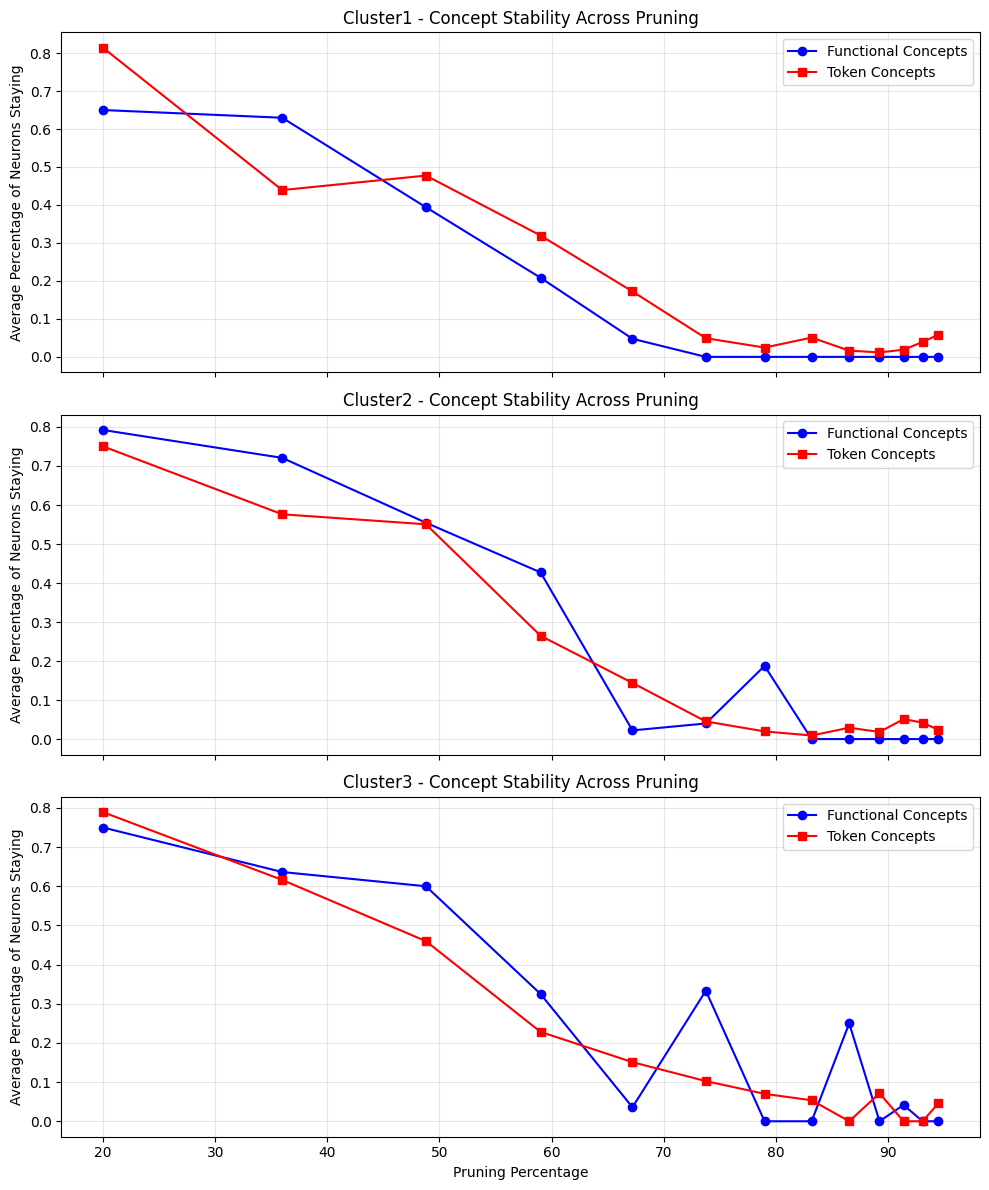

In [194]:
def visualize_concept_stability(graph):
    import matplotlib.pyplot as plt
    import numpy as np
    

    all_prune_iters = set()
    for cluster in graph:
        all_prune_iters.update(graph[cluster].keys())
  
    clusters = sorted(graph.keys())
    fig, axes = plt.subplots(len(clusters), 1, figsize=(10, 4*len(clusters)), sharex=True)
    
    if len(clusters) == 1:
        axes = [axes]  # Make it iterable if there's only one cluster
    
    for i, cluster in enumerate(clusters):
        ax = axes[i]
        

        x_values = []
        functional_values = []
        token_values = []
        
        for pi in prune_percents:
            if pi in graph[cluster]:
                x_values.append(float(pi.replace('% Prune', '')))
                functional_values.append(graph[cluster][pi].get('functional', 0))
                token_values.append(graph[cluster][pi].get('token', 0))
        
        # Plot
        ax.plot(x_values, functional_values, 'b-o', label='Functional Concepts')
        ax.plot(x_values, token_values, 'r-s', label='Token Concepts')
        ax.set_title(f'{cluster} - Concept Stability Across Pruning')
        ax.set_ylabel('Average Percentage of Neurons Staying')
        ax.grid(True, alpha=0.3)
        ax.legend()

    plt.xlabel('Pruning Percentage')
    plt.tight_layout()
    plt.show()
    

visualize_concept_stability(graph)

Cluster transitions

In [ ]:
prune_percents = get_all_pruned_iters(concepts)
def rate_of_neurons_staying_at_cluster(concepts):        
    consistency = collections.defaultdict(dict)
    for concept in concepts.keys():
            
        originally_active_neurons = getActiveNeurons(concepts[concept], '0.0% Prune')
        if not originally_active_neurons: continue
        orig_mask = mask(originally_active_neurons)
        for pi in prune_percents:
            if pi == '0.0% Prune': continue
            neurons_active_at_pi = getActiveNeurons(concepts[concept], pi)
            if not neurons_active_at_pi or len(neurons_active_at_pi)==0:
                movement[concept][pi] = 0
                continue 
            pruned_mask = mask(neurons_active_at_pi)
            consistency_freq = percent_of_neurons_thatStayed_in_same_cluster(orig_mask, pruned_mask)
            
            consistency[concept][pi] = percent_of_neurons_thatStayed_in_same_cluster(orig_mask, pruned_mask)
    return consistency


0.0_Pruning_Iter
19.987_Pruning_Iter
35.97_Pruning_Iter
48.796_Pruning_Iter
59.017_Pruning_Iter
67.22_Pruning_Iter
73.763_Pruning_Iter
79.004_Pruning_Iter
83.203_Pruning_Iter
86.556_Pruning_Iter
89.258_Pruning_Iter
91.406_Pruning_Iter
93.099_Pruning_Iter
94.499_Pruning_Iter


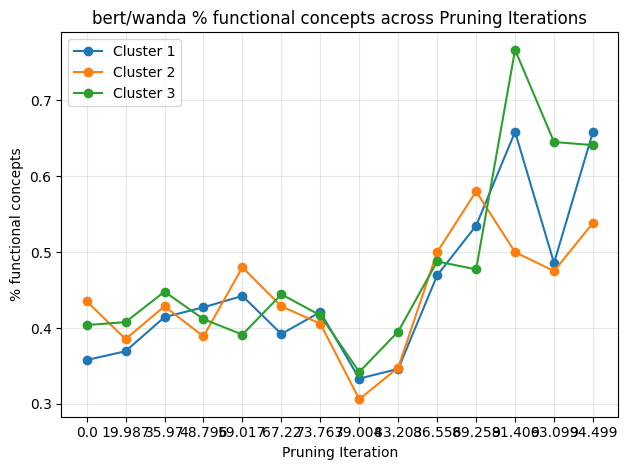

0.0_Pruning_Iter
19.971_Pruning_Iter
35.986_Pruning_Iter
48.779_Pruning_Iter
59.033_Pruning_Iter
67.188_Pruning_Iter
73.779_Pruning_Iter
79.004_Pruning_Iter
83.203_Pruning_Iter
86.572_Pruning_Iter
89.258_Pruning_Iter
91.406_Pruning_Iter
93.115_Pruning_Iter
94.482_Pruning_Iter


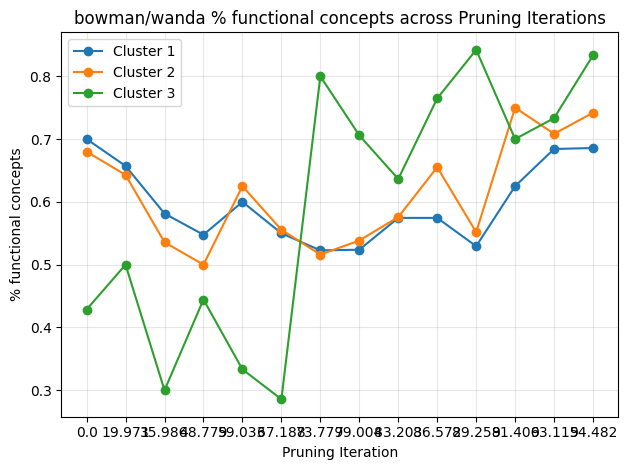

0.0_Pruning_Iter
20.0_Pruning_Iter
36.0_Pruning_Iter
48.8_Pruning_Iter
59.04_Pruning_Iter
67.232_Pruning_Iter
73.786_Pruning_Iter
79.028_Pruning_Iter
83.223_Pruning_Iter
86.578_Pruning_Iter
89.263_Pruning_Iter
91.41_Pruning_Iter
93.128_Pruning_Iter
94.502_Pruning_Iter


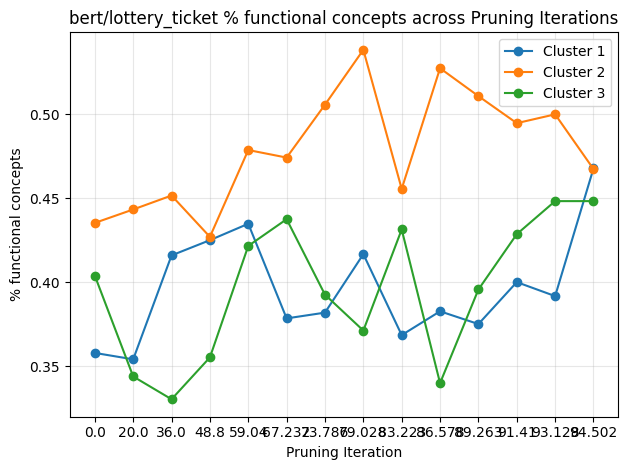

0.0_Pruning_Iter
20.0_Pruning_Iter
36.0_Pruning_Iter
48.8_Pruning_Iter
59.04_Pruning_Iter
67.232_Pruning_Iter
73.786_Pruning_Iter
79.028_Pruning_Iter
83.223_Pruning_Iter
86.578_Pruning_Iter
89.263_Pruning_Iter
91.41_Pruning_Iter
93.128_Pruning_Iter
94.502_Pruning_Iter


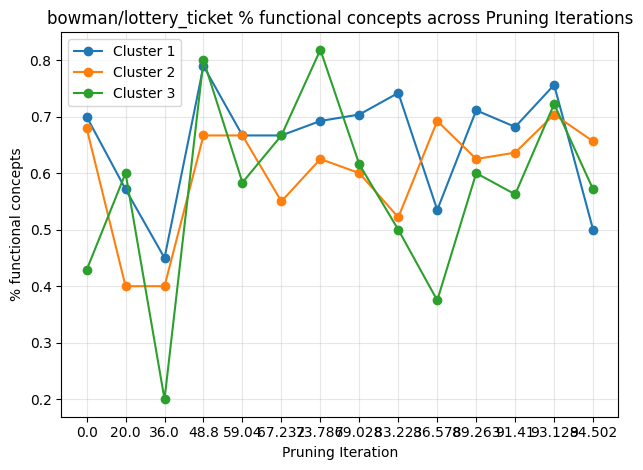

0.0_P


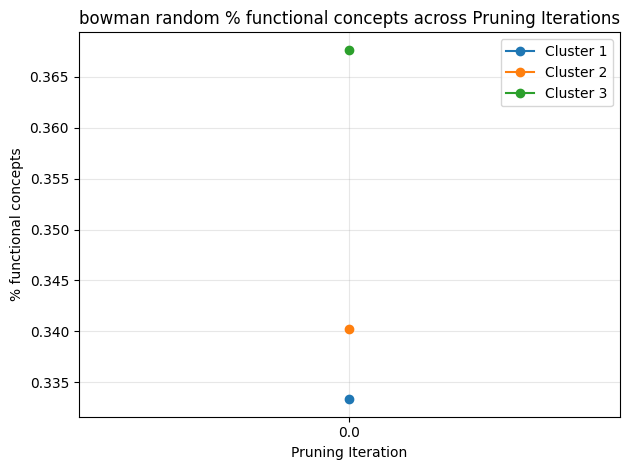

In [64]:

root="bert/wanda/RunBERTToVerifyFormulaMaskOveralpComp"
f_c= set(["at", "in", "is", "there", "on", "to", "are", "for", "has", "not", "their" ,"is", "while", "and", "by", "with", "from", "are", "one", "no", "another", "this", "these", "that", "those", "my", "our", "your", "his", "her", "its", "their", "some", "any", "every", "other", "many", "more", "most", "enough", "few", "less", "much", "either", "neither", "several", "all", "both", "each", "one", "two", "three", "four", "first", "second", "third" ,"last", "can", "have", "be", "do", "could", "has", "am", "does", "will", "had", "is", "did", "would", "having", "are", "done", "shall", "was", "doing", "should", "were", "may", "been", "might", "being", "must", "but", "or", "yet", "nor", "for", "so", "before", "once", "since", "until", "when", "while", "as", "like",  "although", "though", "whereas", "while", "except", "because", "since", "if", "where", "when", "why", "whom", "whose", "which", "what", "how"])
def get_unique_concpets_per_cluster(p_i, cluster):
    cps=set()
    r=pd.read_csv(os.path.join(root, f"{p_i}",f'Cluster{cluster}IOUS1024N.csv'))
    for row in r.iterrows():
        row = row[1]
        form = row.best_name
        cps.update(set(get_indiv_concepts(form)))
    return len(cps) 
def get_concepts_per_cluster(root):
    concepts = collections.defaultdict(lambda : collections.defaultdict(set))
    
    for pruning_iter in os.listdir(root):
        if '.ipynb' in pruning_iter: continue
        pruned_percent = pruning_iter[:pruning_iter.index("_")]
        #for each cluster
        for cluster in os.listdir(os.path.join(root, pruning_iter)):
            if cluster == 'result.csv' or '.ipy' in cluster: continue
  
            cluster_num = cluster[7]
            for row in pd.read_csv(os.path.join(root, pruning_iter, cluster)).iterrows(): #fix this
                row = row[1]
                formula = row.best_name
                formula = get_indiv_concepts(formula)
                concepts[pruning_iter][cluster_num].update(formula)
    return concepts
def functional_concept_count(root):
    all_c = get_concepts_per_cluster(root)
    
    f_ccount=collections.defaultdict(lambda : collections.defaultdict(int))
    for p_i in all_c:
        for clus in all_c[p_i]:
            ct = 0
            for c in all_c[p_i][clus]:
                if ':tag:' in c or ':overlap:' in c:
                    ct+=1
                    continue
                for cc in f_c:
                    sc = f":tok:{cc}"
                    hyp_sc = "hyp"+sc
                    pre_sc = "pre"+sc
                    if hyp_sc in c or pre_sc in c:
                        ct += 1
            uq = get_unique_concpets_per_cluster(p_i, clus)
            f_ccount[p_i][int(clus)] = ct/uq
    return f_ccount


import matplotlib.pyplot as plt
import numpy as np
import collections

def graph_func_concepts(graph,title):
    # Define a graph to hold the IOU values by cluster
    cluster_data = collections.defaultdict(list)

    # Get the pruning iterations (x-values)
    prune_keys = sorted(graph.keys())  # Sorting pruning iterations
    
    # Collect IOU values for each cluster across pruning iterations
    for prune_key in prune_keys:
        print(prune_key)
        prune_data = graph[prune_key]
        
        # For each cluster, get the corresponding IOU value or NaN if not present
        for cluster in sorted(prune_data.keys()):
            # Append the IOU value to the respective cluster's list
            cluster_data[cluster].append(prune_data.get(cluster, np.nan))
    
    # Plot the IOU values for each cluster (separate lines)
    for cluster, y_values in cluster_data.items():
        plt.plot([prune_key[:prune_key.index("_")] for prune_key in prune_keys], y_values, marker='o', label=f"Cluster {cluster}")
        
    
    # Customize the plot
    plt.xlabel('Pruning Iteration')
    plt.ylabel('% functional concepts')
    plt.title(f'{title} % functional concepts across Pruning Iterations')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.legend()
    plt.show()

title = 'bert/wanda'
root="bert/wanda/RunBERTToVerifyFormulaMaskOveralpComp/Expls"
f_ccount = functional_concept_count(root)
graph_func_concepts(f_ccount, title)


title = 'bowman/wanda'
root="bowman/wanda/RunBowmanWandaReformatted/Expls"
f_ccount = functional_concept_count(root)
graph_func_concepts(f_ccount, title)


title = 'bert/lottery_ticket'
root="bert/lottery_ticket/RunBERT_LTHFIXED/Expls/"
f_ccount = functional_concept_count(root)
graph_func_concepts(f_ccount, title)


title = 'bowman/lottery_ticket'
root="bowman/lottery_ticket/RunFIXEDLTH/Expls"
f_ccount = functional_concept_count(root)
graph_func_concepts(f_ccount, title)

title = 'bowman random'
root = "random/bowman_new_weightsforfixedlth/expls"
f_ccount = functional_concept_count(root)
graph_func_concepts(f_ccount, title)

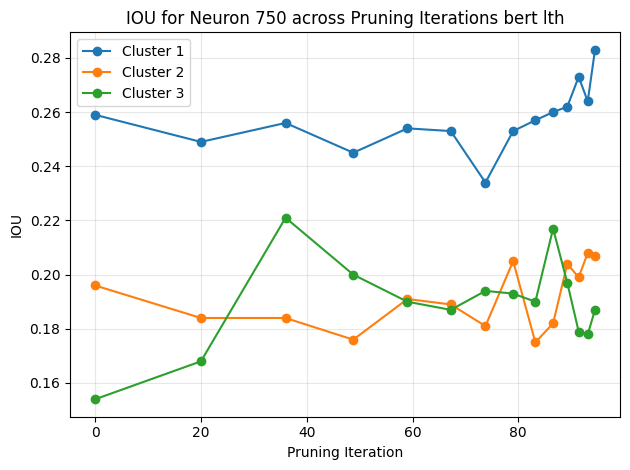

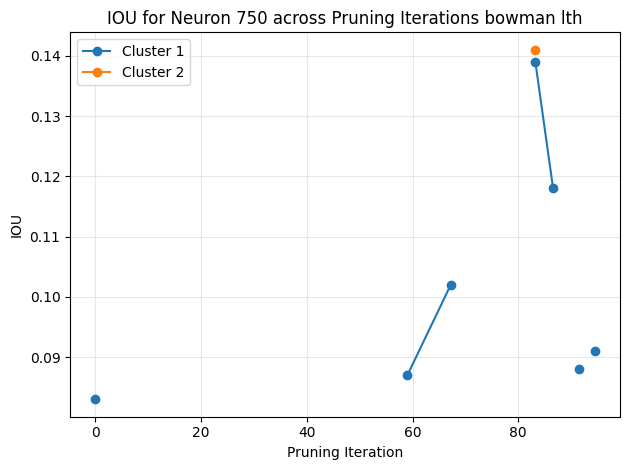

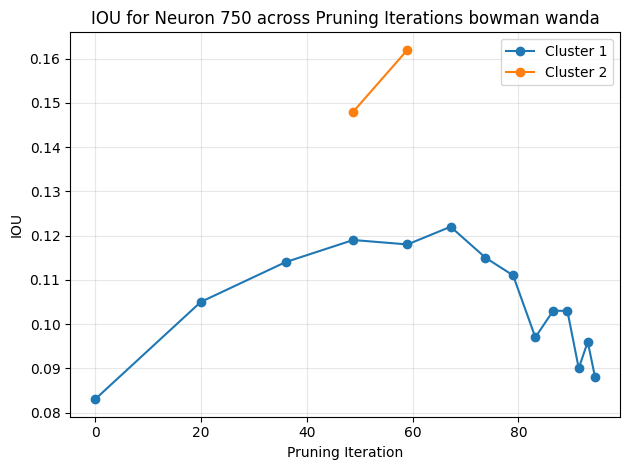

FileNotFoundError: [Errno 2] No such file or directory: 'bert/wanda/RunBERT/Expls/'

In [59]:
                
def get_ious(root):
    ious = collections.defaultdict(lambda : collections.defaultdict(lambda : collections.defaultdict(list)))
    #for each pruning iter
    for pruning_iter in os.listdir(root):
        if '.ipynb' in pruning_iter: continue
        pruned_percent = pruning_iter[:pruning_iter.index("_")]
        #for each cluster
        for cluster in os.listdir(os.path.join(root, pruning_iter)):
            if cluster == 'result.csv' or '.ipy' in cluster: continue
  
            cluster_num = cluster[7]
            for row in pd.read_csv(os.path.join(root, pruning_iter, cluster)).iterrows(): #fix this
                row = row[1]
                neuron, iou = row.unit ,float("{:.3f}".format(row.best_iou))
                ious[float(pruning_iter[:pruning_iter.index("_")])][neuron][cluster_num]=iou
    return ious

import collections
import matplotlib.pyplot as plt
def graph_change_iou(neuron,title, ious):
    # Dictionary to store IOU values by pruning iteration
    graph = collections.defaultdict(lambda: {})
    
    # Collect IOU values for the specified neuron at each pruning iteration
    for prune_key, prune_data in ious.items():
        if neuron in prune_data:
            # For each cluster in the current pruning iteration, store its IOU
            for cluster, iou in prune_data[neuron].items():
                graph[cluster][prune_key] = iou  # Store the IOU for this cluster and prune iteration
    
    # Get the pruning iterations (x-values)
    x_values = sorted(ious.keys())  # Sorting to ensure correct order of pruning iterations
    
    # Plotting the IOU values for each cluster (separate lines)
    for cluster, cluster_data in graph.items():
        y_values = []
        for prune_key in x_values:
            # If the cluster doesn't exist for this pruning iteration, append NaN
            y_values.append(cluster_data.get(prune_key, np.nan))
        
        # Plot the line for the current cluster
        plt.plot(x_values, y_values, marker='o', label=f"Cluster {cluster}")
    
    # Customize the plot
    plt.xlabel('Pruning Iteration')
    plt.ylabel('IOU')
    plt.title(f'IOU for Neuron {neuron} across Pruning Iterations {title}')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.legend()
    plt.show()
root="bert/lottery_ticket/RunBERT_LTHFIXED/Expls/"
ious=get_ious(root)
title='bert lth'

neuron=750
graph_change_iou(neuron, title, ious)

root="bowman/lottery_ticket/RunFIXEDLTH/Expls"
ious=get_ious(root)
title='bowman lth'
graph_change_iou(neuron, title, ious)

root="bowman/wanda/RunBowmanWandaReformatted/Expls"
ious=get_ious(root)
title='bowman wanda'
graph_change_iou(neuron, title, ious)

root="bert/wanda/RunBERT/Expls/"
ious=get_ious(root)
title='bert wanda'
graph_change_iou(neuron, title, ious)

In [60]:
num = {'Cluster1': 0, 'Cluster2': 0, 'Cluster3': 0}
clus='Cluster1'
concept= "NOT hyp:tok:sleeping"
for perc, order in concepts[concept].items():
    num_active_neurs = 0
    all_active_neurons = order[clus] 
    num[clus] += len(all_active_neurons)
print(f"For concept {concept} {clus} on average {num[clus]/len(concepts[concept])}")
find_concept_details("NOT hyp:tok:sleeping")

For concept NOT hyp:tok:sleeping Cluster1 on average 4.642857142857143
In original at 
	Cluster 1: ['Neuron 250: IOU:0.245', 'Neuron 475: IOU:0.238', 'Neuron 750: IOU:0.259']
	Cluster 2: []
	Cluster 3: []
At 20.0% Prune% at 
	Cluster 1: ['Neuron 250: IOU:0.264', 'Neuron 725: IOU:0.249', 'Neuron 750: IOU:0.249']
	Cluster 2: []
	Cluster 3: []
At 36.0% Prune% at 
	Cluster 1: ['Neuron 0: IOU:0.262', 'Neuron 250: IOU:0.26', 'Neuron 750: IOU:0.256', 'Neuron 825: IOU:0.278']
	Cluster 2: []
	Cluster 3: []
At 48.8% Prune% at 
	Cluster 1: ['Neuron 250: IOU:0.269', 'Neuron 700: IOU:0.238', 'Neuron 750: IOU:0.245']
	Cluster 2: ['Neuron 725: IOU:0.222']
	Cluster 3: []
At 59.04% Prune% at 
	Cluster 1: ['Neuron 250: IOU:0.251', 'Neuron 275: IOU:0.271', 'Neuron 700: IOU:0.243', 'Neuron 725: IOU:0.247', 'Neuron 750: IOU:0.254']
	Cluster 2: ['Neuron 75: IOU:0.211', 'Neuron 725: IOU:0.218']
	Cluster 3: []
At 67.232% Prune% at 
	Cluster 1: ['Neuron 25: IOU:0.23', 'Neuron 175: IOU:0.255', 'Neuron 250: IOU:

In [4]:
num={}
for concept in concepts:
    clus='Cluster3'
    cts=0
    for perc, order in concepts[concept].items():
        num_active_neurs = 0
        all_active_neurons = order[clus] 
        cts += len(all_active_neurons)
    num[concept]=cts
    #print("for ", concept, " there are ", num[concept], " counts")
sum(num.values())/len(num) 

3.5504201680672267

In [5]:
def get_all_concepts(formula) -> list:
    concepts = []
    concps = re.findall(r'\b(?:NOT )?(?:pre:tok:|pre:tag:|hyp:tag:|hyp:tok:|oth:)\S*', formula)
    
    for i in range(len(concps)):
        try:
            end_idx = concps[i].index(')')
            concepts.append(concps[i][:end_idx])
        except:
            concepts.append(concps[i])
    return concepts

In [6]:
#iou hanges
import random
cluster='Cluster1'
concept=random.choice(list(concepts.keys()))
ious=collections.defaultdict(list)
for per, expl in concepts[concept].items():
    for neuriou in expl[cluster]:
        iou = neuriou.rfind(":")
        iou = neuriou[iou+1:]
        ious[per].append(iou)
myKeys = list(ious.keys())
myKeys.sort()

# Sorted Dictionary
sd = {i: ious[i] for i in myKeys}
print(concept)
sd

pre:tok:smiling


{}

In [7]:
concepts['NOT hyp:tok:not']

{'86.578% Prune': {'Cluster1': ['Neuron 250: IOU:0.244',
   'Neuron 950: IOU:0.254'],
  'Cluster2': [],
  'Cluster3': []},
 '93.128% Prune': {'Cluster1': ['Neuron 50: IOU:0.262',
   'Neuron 600: IOU:0.248',
   'Neuron 975: IOU:0.276'],
  'Cluster2': [],
  'Cluster3': []},
 '94.502% Prune': {'Cluster1': ['Neuron 50: IOU:0.254',
   'Neuron 175: IOU:0.245',
   'Neuron 250: IOU:0.249',
   'Neuron 950: IOU:0.269'],
  'Cluster2': [],
  'Cluster3': []},
 '91.41% Prune': {'Cluster1': ['Neuron 50: IOU:0.253',
   'Neuron 250: IOU:0.241',
   'Neuron 675: IOU:0.262'],
  'Cluster2': [],
  'Cluster3': []}}

In [8]:
sparsity['NOT hyp:tok:running']

NameError: name 'sparsity' is not defined

In [174]:
import matplotlib.pyplot as plt
import numpy as np
f_c= set(["at", "in", "is", "there", "on", "to", "are", "for", "has", "not", "their" ,"is", "while", "and", "by", "with", "from", "are", "one", "no", "another", "this", "these", "that", "those", "my", "our", "your", "his", "her", "its", "their", "some", "any", "every", "other", "many", "more", "most", "enough", "few", "less", "much", "either", "neither", "several", "all", "both", "each", "one", "two", "three", "four", "first", "second", "third" ,"last", "can", "have", "be", "do", "could", "has", "am", "does", "will", "had", "is", "did", "would", "having", "are", "done", "shall", "was", "doing", "should", "were", "may", "been", "might", "being", "must", "but", "or", "yet", "nor", "for", "so", "before", "once", "since", "until", "when", "while", "as", "like",  "although", "though", "whereas", "while", "except", "because", "since", "if", "where", "when", "why", "whom", "whose", "which", "what", "how"])

def check_sparsity(concepts):
    sparsity = {}
    for concept in concepts:
        if concept[concept.rfind(":")+1:] in f_c: continue
            
        #num of prune iters concept is defined at / ttal num of prune iters
        pruning_sparsity = len(concepts[concept]) / 14
        avg_cluster_sparsity=0
        for percents, clusters in concepts[concept].items():
            active_clusters = 0
            for list_ in clusters:
                if len(concepts[concept][percents][list_]) > 0:
                    active_clusters += 1
            avg_cluster_sparsity  += (active_clusters/len(concepts[concept]))
        sparsity[concept] = {'Pruning sparsity': pruning_sparsity, "Cluster Sparsity":avg_cluster_sparsity }
    return sparsity

def get_prune_sparsity(sparsity):
    pruning_sparisty=[]
    lessthan5pruneiters=[]
    for concept in sparsity:
        if sparsity[concept]['Pruning sparsity'] < 0.6:
            lessthan5pruneiters.append(concept)
        pruning_sparisty.append(sparsity[concept]['Pruning sparsity'])
    return pruning_sparisty, lessthan5pruneiters

def get_cluster_sparsity(sparsity):
    cluster_sparsity=[]
    for concept in sparsity:
        cluster_sparsity.append(sparsity[concept]['Cluster Sparsity'])
    return cluster_sparsity

def get_avg_prune_sparsity(sparsity):
    pruning_sparisty,cluster_sparsity = 0,0
    for concept in sparsity:
        pruning_sparisty += sparsity[concept]['Pruning sparsity']
        cluster_sparsity += sparsity[concept]['Cluster Sparsity']
    print(pruning_sparisty/len(sparsity), cluster_sparsity/len(sparsity))

def box_plot(data,title):
    
    fig = plt.figure(figsize =(10, 7))
    plt.title(title)
    # Creating plot
    plt.boxplot(data)

    # show plot
    plt.show()
#Pruning sparsity: how many pruning iterations a concept ends up at (1 means all iterations 0 means none)
#Cluster sparsity: how many clusters within a pruning iter does a concept end up at (1 means all (for a single pruning iter), 0 means none)

In [175]:
gps, lessthan5pruneiters=get_prune_sparsity(sparsity)
ct=0
for i in lessthan5pruneiters:
    if i[i.rfind(":")+1:] in f_c or ':tag:' in i or ':overlap:' in i:
        ct+=1
ct, len(lessthan5pruneiters)

(58, 467)

0.24257975034673934 1.1613426810514187


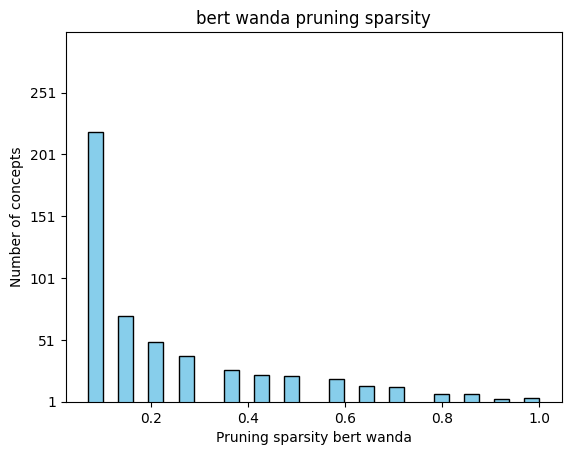

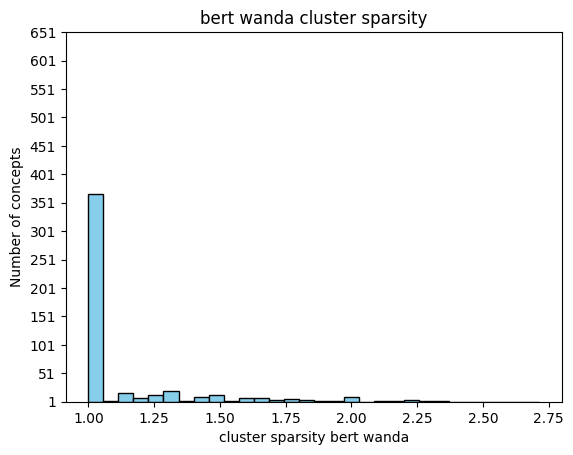

In [142]:
#wanda bert
root="bert/wanda/RunBERTToVerifyFormulaMaskOveralpComp/Expls"
concepts=get_collected_concepts(root)

sparsity = check_sparsity(concepts)
get_avg_prune_sparsity(sparsity)
#box_plot(get_cluster_sparsity(sparsity))
plt.hist(get_prune_sparsity(sparsity), bins=30, color='skyblue', edgecolor='black')
plt.ylim(1.0, 300)  # Set y-axis limits to match box plot
y_ticks = np.arange(1.0, 300, 50)
plt.yticks(y_ticks)
plt.title("bert wanda pruning sparsity")
plt.xlabel("Pruning sparsity bert wanda")
plt.ylabel("Number of concepts")
plt.show()

plt.hist(get_cluster_sparsity(sparsity), bins=30, color='skyblue', edgecolor='black')
plt.ylim(1.0, 300)  # Set y-axis limits to match box plot
y_ticks = np.arange(1.0, 700, 50)
plt.yticks(y_ticks)
plt.title("bert wanda cluster sparsity")
plt.xlabel("cluster sparsity bert wanda")
plt.ylabel("Number of concepts")
plt.show()

0.317827130852345 1.1386390958869956
0.317827130852345 1.1386390958869956


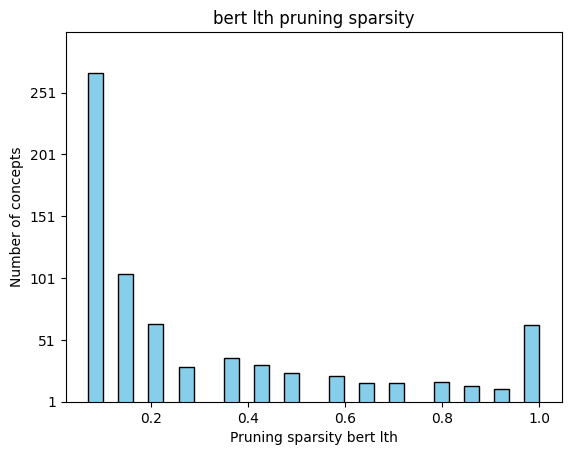

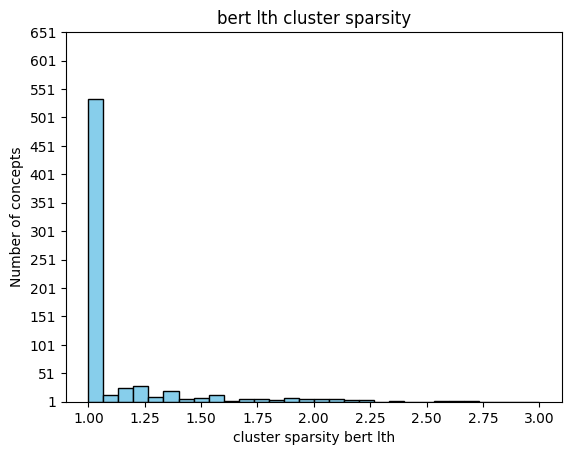

In [97]:
#lt bert
root="bert/lottery_ticket/RunBERT_LTHFIXED/Expls/" 
concepts=get_collected_concepts(root)

sparsity = check_sparsity(concepts)
get_avg_prune_sparsity(sparsity)
sparsity = check_sparsity(concepts)
get_avg_prune_sparsity(sparsity)
#box_plot(get_cluster_sparsity(sparsity))
plt.hist(get_prune_sparsity(sparsity), bins=30, color='skyblue', edgecolor='black')
plt.ylim(1.0, 300)  # Set y-axis limits to match box plot
y_ticks = np.arange(1.0, 300, 50)
plt.yticks(y_ticks)
plt.title("bert lth pruning sparsity")
plt.xlabel("Pruning sparsity bert lth")
plt.ylabel("Number of concepts")
plt.show()

plt.hist(get_cluster_sparsity(sparsity), bins=30, color='skyblue', edgecolor='black')
plt.ylim(1.0, 300)  # Set y-axis limits to match box plot
y_ticks = np.arange(1.0, 700, 50)
plt.yticks(y_ticks)
plt.title("bert lth cluster sparsity")
plt.xlabel("cluster sparsity bert lth")
plt.ylabel("Number of concepts")
plt.show()

0.20665212649945422 1.0859922202479453
0.20665212649945422 1.0859922202479453


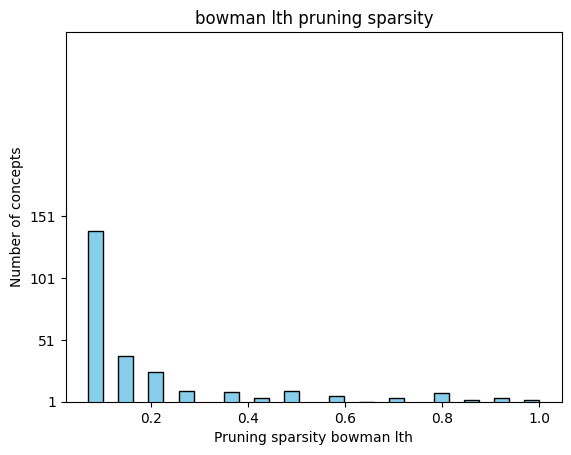

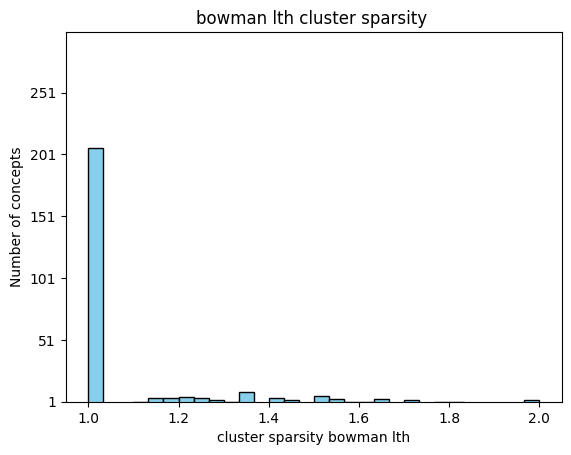

In [98]:
#lt bowman
root= "bowman/lottery_ticket/RunFIXEDLTH/Expls" 
concepts=get_collected_concepts(root)

sparsity = check_sparsity(concepts)
get_avg_prune_sparsity(sparsity)
sparsity = check_sparsity(concepts)
get_avg_prune_sparsity(sparsity)
#box_plot(get_cluster_sparsity(sparsity))
plt.hist(get_prune_sparsity(sparsity), bins=30, color='skyblue', edgecolor='black')
plt.ylim(1.0, 300)  # Set y-axis limits to match box plot
y_ticks = np.arange(1.0, 200, 50)
plt.yticks(y_ticks)
plt.title("bowman lth pruning sparsity")
plt.xlabel("Pruning sparsity bowman lth")
plt.ylabel("Number of concepts")
plt.show()

plt.hist(get_cluster_sparsity(sparsity), bins=30, color='skyblue', edgecolor='black')
plt.ylim(1.0, 300)  # Set y-axis limits to match box plot
y_ticks = np.arange(1.0, 300, 50)
plt.yticks(y_ticks)
plt.title("bowman lth cluster sparsity ")
plt.xlabel("cluster sparsity bowman lth")
plt.ylabel("Number of concepts")
plt.show()

0.22582228767795756 1.1021398990471158


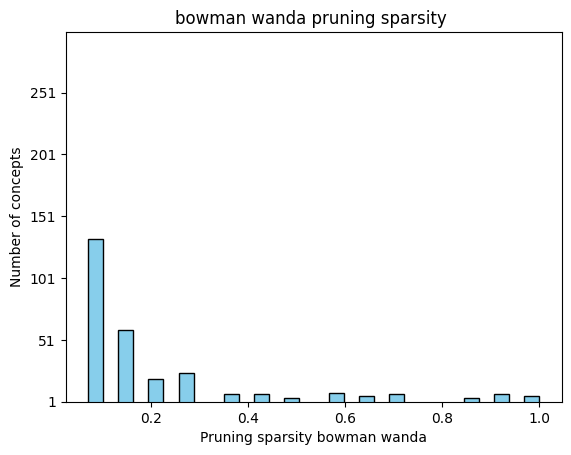

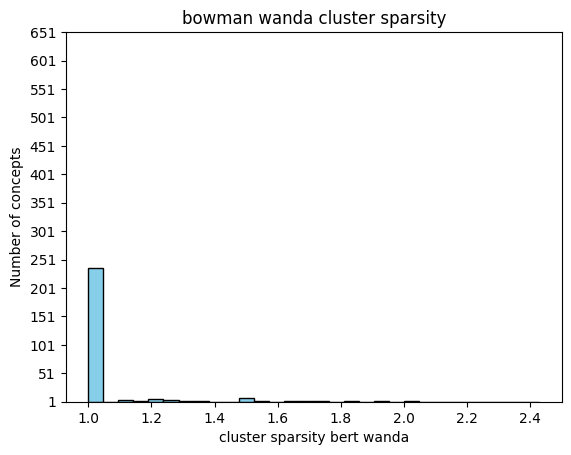

In [99]:
#wanda bowman
root="bowman/wanda/RunBowmanWandaReformatted/Expls" 
concepts=get_collected_concepts(root)

sparsity = check_sparsity(concepts)
get_avg_prune_sparsity(sparsity)
#box_plot(get_cluster_sparsity(sparsity))
plt.hist(get_prune_sparsity(sparsity), bins=30, color='skyblue', edgecolor='black')
plt.ylim(1.0, 300)  # Set y-axis limits to match box plot
y_ticks = np.arange(1.0, 300, 50)
plt.yticks(y_ticks)
plt.title("bowman wanda pruning sparsity ")
plt.xlabel("Pruning sparsity bowman wanda")
plt.ylabel("Number of concepts")
plt.show()

plt.hist(get_cluster_sparsity(sparsity), bins=30, color='skyblue', edgecolor='black')
plt.ylim(1.0, 300)  # Set y-axis limits to match box plot
y_ticks = np.arange(1.0, 700, 50)
plt.yticks(y_ticks)
plt.title("bowman wanda cluster sparsity")
plt.xlabel("cluster sparsity bert wanda")
plt.ylabel("Number of concepts")
plt.show()

In [ ]:
get_cluster_sparsity(sparsity)